In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI

## MIPHEI

https://github.com/sanofi-public/miphei-vit
- miphei env
- predicting multiplex immunofluorescence (mIF) from standard H&E-stained histology images.


In [2]:
# # Clone Hugging Face model

# !git lfs install  # only needed once, if not already done
# !git clone https://huggingface.co/Estabousi/MIPHEI-vit
# %cd MIPHEI-vit
# # Install dependencies for MIPHEI-VIT inference
# !pip install -r requirements.txt -q

# # Install CellPose for cell segmentation
# !pip install cellpose==3.1.1.2 scikit-image scipy -q

In [3]:
# import timm
# model = timm.create_model("hf_hub:Estabousi/MIPHEI-vit", pretrained=True)

In [4]:
# Note: path, therapy_data, segment_data, export_data are already defined in Cell 2
# This cell is kept for reference but variables are not redefined here
# If you need to modify these values, do it in Cell 2
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
segment_data = 'NCRT_project - seg 1-14'
export_data = 'export'

In [5]:
# path = '/home/lingyu/data/Python/Collaborate/esccAI/'
# checkpoint_dir = f"{path}/model/MIPHEI-ViT/checkpoints_Lily/MIPHEI-ViT" # select the checkpoint directory
# MPP = 0.5  # Set to None if you don't know the mpp of the input images. Best is 0.5 mpp
# IMAGE_PATH = f"{path}/data/NCRT/NCRT HE.qptiff"

In [6]:
# MIPHEI-ViT Configuration
# Reference: https://github.com/sanofi-public/miphei-vit
# Note: path and therapy_data are defined in Cell 2

# Add MIPHEI-ViT to Python path
miphei_path = f"{path}Collaborate/esccAI/model/MIPHEI-ViT"
import sys
if miphei_path not in sys.path:
    sys.path.insert(0, miphei_path)

# Checkpoint configuration
# Option 1: Use local checkpoint directory (must contain model.safetensors and config.yaml)
checkpoint_dir = f"{path}Collaborate/esccAI/model/MIPHEI-ViT/checkpoints_Lily/MIPHEI-ViT"

# Option 2: Use Hugging Face model (alternative if local checkpoint is not available)
USE_HUGGINGFACE = False  # Set to True to use Hugging Face model instead
HF_MODEL_NAME = "hf_hub:Estabousi/MIPHEI-vit"

MPP = 0.5  # Set to None if you don't know the mpp of the input images. Best is 0.5 mpp
IMAGE_PATH = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff"

# Check checkpoint directory structure
from pathlib import Path
checkpoint_path_safetensors = Path(checkpoint_dir) / "model.safetensors"
checkpoint_path_ckpt = Path(checkpoint_dir) / "model.ckpt"
config_path = Path(checkpoint_dir) / "config.yaml"
hemit_pth = Path(checkpoint_dir) / "hemit_v1.pth"

print("="*60)
print("MIPHEI-ViT Configuration Check")
print("="*60)
print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Image path: {IMAGE_PATH}")
print(f"MIPHEI-ViT path: {miphei_path}")

# Check what files exist
print("\nChecking checkpoint files...")
has_safetensors = checkpoint_path_safetensors.exists()
has_ckpt = checkpoint_path_ckpt.exists()
has_config = config_path.exists()
has_hemit = hemit_pth.exists()

print(f"  model.safetensors: {'✓' if has_safetensors else '✗'}")
print(f"  model.ckpt: {'✓' if has_ckpt else '✗'}")
print(f"  config.yaml: {'✓' if has_config else '✗'}")
print(f"  hemit_v1.pth: {'✓' if has_hemit else '✗'}")

# Determine checkpoint type
if has_safetensors or has_ckpt:
    if has_config:
        print("\n✓ Standard MIPHEI-ViT checkpoint found!")
        USE_HUGGINGFACE = False
    else:
        print("\n⚠ Warning: Checkpoint file found but config.yaml is missing!")
        print("  Please ensure config.yaml exists in the checkpoint directory.")
elif has_hemit:
    print("\n⚠ Warning: Only hemit_v1.pth found. This is not a standard MIPHEI-ViT checkpoint.")
    print("  Standard checkpoint should contain:")
    print("    - model.safetensors (or model.ckpt)")
    print("    - config.yaml")
    print("    - logreg.pth (optional, for cell type classification)")
    print("\n  Options:")
    print("  1. Download standard checkpoint from:")
    print("     - GitHub releases: https://github.com/sanofi-public/miphei-vit/releases")
    print("     - Weights & Biases: https://wandb.ai/guillaume-balezo/MIPHEI-ViT_paper/artifacts/")
    print("  2. Use Hugging Face model (set USE_HUGGINGFACE = True)")
    print("  3. Run: python scripts/download_checkpoints.py (from MIPHEI-ViT directory)")
    USE_HUGGINGFACE = True  # Auto-switch to HF if no standard checkpoint
else:
    print("\n✗ No checkpoint files found!")
    print("  Please download a checkpoint or set USE_HUGGINGFACE = True")
    USE_HUGGINGFACE = True

if USE_HUGGINGFACE:
    print(f"\n→ Will use Hugging Face model: {HF_MODEL_NAME}")
    print("  Note: You may need to install timm and have internet access")
else:
    print(f"\n→ Will use local checkpoint: {checkpoint_dir}")

print("="*60)

MIPHEI-ViT Configuration Check
Checkpoint directory: /home/lingyu/data/Python/Collaborate/esccAI/model/MIPHEI-ViT/checkpoints_Lily/MIPHEI-ViT
Image path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
MIPHEI-ViT path: /home/lingyu/data/Python/Collaborate/esccAI/model/MIPHEI-ViT

Checking checkpoint files...
  model.safetensors: ✓
  model.ckpt: ✗
  config.yaml: ✓
  hemit_v1.pth: ✗

✓ Standard MIPHEI-ViT checkpoint found!

→ Will use local checkpoint: /home/lingyu/data/Python/Collaborate/esccAI/model/MIPHEI-ViT/checkpoints_Lily/MIPHEI-ViT


In [7]:
# Install MIPHEI-ViT dependencies if not already installed
# Option 1: Install from requirements.txt (recommended)
# Option 2: Install individual missing packages (below)

import subprocess
import sys
from pathlib import Path

# Get MIPHEI-ViT path (defined in Cell 40, or use default)
try:
    miphei_path_var = miphei_path
except NameError:
    # Fallback if miphei_path is not defined yet
    miphei_path_var = f"{path}Collaborate/esccAI/model/MIPHEI-ViT"

# Try to install from requirements.txt first
requirements_path = Path(miphei_path_var) / "requirements.txt"
if requirements_path.exists():
    print(f"Installing dependencies from {requirements_path}...")
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-r", str(requirements_path), "-q"
        ])
        print("✓ All dependencies installed from requirements.txt")
    except subprocess.CalledProcessError as e:
        print(f"✗ Failed to install from requirements.txt: {e}")
        print("Trying to install individual packages...")
        
        # Fallback: install individual packages
        required_packages = [
            'omegaconf>=2.3.0',
            'cellpose>=3.1.1',
            'albumentations>=2.0.5',
            'safetensors>=0.5.3',
            'timm>=1.0.15',
            'scikit-image>=0.25.2',
            'scipy>=1.15.2',
        ]
        
        for package in required_packages:
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
                print(f"✓ Installed {package}")
            except subprocess.CalledProcessError:
                print(f"✗ Failed to install {package}")
else:
    print(f"Requirements file not found at {requirements_path}")
    print("Installing essential packages individually...")
    
    essential_packages = [
        'omegaconf',
        'cellpose',
        'albumentations',
        'safetensors',
        'timm',
        'scikit-image',
        'scipy',
    ]
    
    for package in essential_packages:
        try:
            __import__(package)
            print(f"✓ {package} is already installed")
        except ImportError:
            print(f"Installing {package}...")
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
                print(f"✓ Installed {package}")
            except subprocess.CalledProcessError:
                print(f"✗ Failed to install {package}")

print("\n" + "="*60)
print("If you still encounter import errors, please:")
print("1. Make sure you're using the 'miphei' conda environment")
print("2. Run: conda activate miphei")
print("3. Run: pip install -r requirements.txt (from MIPHEI-ViT directory)")
print("="*60)

Installing dependencies from /home/lingyu/data/Python/Collaborate/esccAI/model/MIPHEI-ViT/requirements.txt...


✓ All dependencies installed from requirements.txt

If you still encounter import errors, please:
1. Make sure you're using the 'miphei' conda environment
2. Run: conda activate miphei
3. Run: pip install -r requirements.txt (from MIPHEI-ViT directory)


In [8]:
# Import MIPHEI-ViT packages
# IMPORTANT: Make sure Cell 41 has been run first to set up the path!

# Check if miphei_path is defined (from Cell 41)
if 'miphei_path' not in globals():
    raise RuntimeError(
        "Please run Cell 41 first to set up MIPHEI-ViT paths!\n"
        "Cell 41 adds the MIPHEI-ViT directory to sys.path, which is required for importing src modules."
    )

from omegaconf import OmegaConf
from cellpose import models
import json
import albumentations as A
from pathlib import Path
import torch
from safetensors.torch import load_file
from timm.layers import resample_abs_pos_embed
from PIL import Image
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import binary_dilation, disk

# Define get_effective_width_height locally to avoid pyvips import issue
# This function doesn't actually need pyvips, but dataset.py imports it at the top
def get_effective_width_height(width: int, height: int, train: bool = False):
    """
    Calculate the effective width and height, optionally rounding down to the nearest power of 2.
    This avoids importing dataset.py which has pyvips dependency issues.
    """
    if train:
        # Calculate the largest power of 2 less than or equal to width and height
        width = int(2 ** (np.floor(np.log2(width))))
        height = int(2 ** (np.floor(np.log2(height))))
    return width, height

# Import MIPHEI-ViT src modules (requires miphei_path to be in sys.path)
# Note: We avoid importing from src.dataset due to pyvips dependency issues
# generators and utils don't depend on dataset.py, so they should import fine
try:
    from src.generators import get_generator
    from src.utils import MeanCellExtrator
    print("✓ Successfully imported MIPHEI-ViT modules")
except ImportError as e:
    error_msg = str(e).lower()
    if 'pyvips' in error_msg or 'libvips' in error_msg or 'dataset' in error_msg:
        print("Warning: pyvips/dataset import issue detected.")
        print("Attempting to import modules directly without going through __init__...")
        
        # Try direct import to avoid any __init__ imports that might trigger dataset.py
        import importlib.util
        import sys
        
        # Import generators directly
        generators_init = Path(miphei_path) / "src" / "generators" / "__init__.py"
        if generators_init.exists():
            spec = importlib.util.spec_from_file_location("src.generators", generators_init)
            generators_mod = importlib.util.module_from_spec(spec)
            sys.modules["src.generators"] = generators_mod
            spec.loader.exec_module(generators_mod)
            get_generator = generators_mod.get_generator
            print("✓ Loaded get_generator")
        
        # Import utils directly
        utils_file = Path(miphei_path) / "src" / "utils.py"
        if utils_file.exists():
            spec = importlib.util.spec_from_file_location("src.utils", utils_file)
            utils_mod = importlib.util.module_from_spec(spec)
            sys.modules["src.utils"] = utils_mod
            spec.loader.exec_module(utils_mod)
            MeanCellExtrator = utils_mod.MeanCellExtrator
            print("✓ Loaded MeanCellExtrator")
        else:
            raise ImportError(f"Could not find utils.py at {utils_file}")
    else:
        raise ImportError(
            f"Failed to import MIPHEI-ViT modules. Error: {e}\n"
            f"Make sure you have:\n"
            f"1. Run Cell 41 to set up paths\n"
            f"2. Activated the 'miphei' conda environment\n"
            f"3. Installed all dependencies (Cell 42)"
        )

def validate_load_info(load_info):
    """
    Validates the result of model.load_state_dict(..., strict=False).
    """
    if load_info.unexpected_keys:
        raise ValueError(f"Unexpected keys in state_dict: {load_info.unexpected_keys}")
    
    for key in load_info.missing_keys:
        if ".lora" in key:
            raise ValueError(f"Missing LoRA checkpoint in state_dict: {key}")
        elif not any(part in key for part in ["encoder.vit.", "encoder.model."]):
            raise ValueError(f"Missing key in state_dict: {key}")

def inference_cellpose(x, cellpose_model, radius=None):
    """Run CellPose inference for nuclei segmentation."""
    nuclei_mask, _, _, _ = cellpose_model.eval(
        x,
        channels=[0, 0],
        diameter=None,
        min_size=15,
        normalize=True,
        invert=True,
        flow_threshold=0.4,
    )
    
    if radius is not None:
        # watershed nuclei expansion
        binary = nuclei_mask > 0
        dilated_mask = binary_dilation(binary, footprint=disk(radius))
        distance = ndi.distance_transform_edt(~binary)
        nuclei_mask = watershed(-distance, markers=nuclei_mask, mask=dilated_mask, watershed_line=False)
    return nuclei_mask

def create_nuclei_types(nuclei_mask_torch, cell_predictions, cell_ids):
    """Create binary masks for each cell type."""
    height, width = nuclei_mask_torch.shape[2], nuclei_mask_torch.shape[3]
    nuclei_types_torch = torch.zeros((1, 15, height, width), dtype=torch.bool)
    
    for idx_class in range(15):
        cell_ids_class = cell_ids[cell_predictions[..., idx_class]]
        nuclei_types_torch[:, idx_class] = torch.isin(nuclei_mask_torch, cell_ids_class).cpu()
    return nuclei_types_torch

print("MIPHEI-ViT packages imported successfully")

/home/lingyu/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lingyu/ssd/anaconda3/env/envs/miphei/lib/python3.11/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


✓ Successfully imported MIPHEI-ViT modules
MIPHEI-ViT packages imported successfully


In [9]:
# Load model configuration and checkpoint
# This cell must be run before initializing models
print("Loading model configuration...")

if USE_HUGGINGFACE:
    # Use Hugging Face model - create minimal config
    print("Using Hugging Face model - creating minimal configuration...")
    
    # Default channel names for MIPHEI-ViT (from ORION dataset)
    default_channel_names = [
        "Hoechst", "CD31", "CD45", "CD68", "CD4", "FOXP3", "CD8a", 
        "CD45RO", "CD20", "PD-L1", "CD3e", "CD163", "E-cadherin", 
        "Ki67", "Pan-CK", "SMA"
    ]
    
    # Create minimal config
    cfg = OmegaConf.create({
        "model": {
            "model_name": "mipheivit",
            "encoder": {
                "encoder_name": "hoptimus0",
                "encoder_weights": None
            }
        },
        "data": {
            "targ_channel_names": default_channel_names,
            "channel_stats_path": "channel_stats.json"
        }
    })
    
    # Try to load channel stats from MIPHEI-ViT directory
    channel_stats_path = Path(miphei_path) / "channel_stats.json"
    if not channel_stats_path.exists():
        channel_stats_path = Path(miphei_path) / "channel_stats_hemit.json"
    
    if channel_stats_path.exists():
        with open(channel_stats_path, "r") as f:
            channel_stats = json.load(f)
    else:
        print("⚠ Warning: channel_stats.json not found, using default values")
        channel_stats = {}
    
    nc_out = len(default_channel_names)
    nc_in = 3
    default_width = default_height = 256
    
    checkpoint_path = None  # Will use Hugging Face model directly
    
    print(f"Model configuration (Hugging Face):")
    print(f"  Input channels: {nc_in}")
    print(f"  Output channels: {nc_out}")
    print(f"  Default size: {default_width}x{default_height}")
    print(f"  Channel names: {default_channel_names}")
    
    channel_names = default_channel_names
    
else:
    # Use local checkpoint
    checkpoint_path_safetensors = Path(checkpoint_dir) / "model.safetensors"
    checkpoint_path_ckpt = Path(checkpoint_dir) / "model.ckpt"
    config_path = Path(checkpoint_dir) / "config.yaml"
    
    # Determine checkpoint file
    if checkpoint_path_safetensors.exists():
        checkpoint_path = str(checkpoint_path_safetensors)
    elif checkpoint_path_ckpt.exists():
        checkpoint_path = str(checkpoint_path_ckpt)
    else:
        raise FileNotFoundError(
            f"No checkpoint file found in {checkpoint_dir}\n"
            f"Expected: model.safetensors or model.ckpt\n"
            f"Please download a checkpoint or set USE_HUGGINGFACE = True"
        )
    
    if not config_path.exists():
        raise FileNotFoundError(
            f"Config file not found: {config_path}\n"
            f"Standard MIPHEI-ViT checkpoint must include config.yaml\n"
            f"Please download a complete checkpoint or set USE_HUGGINGFACE = True"
        )
    
    cfg = OmegaConf.load(config_path)
    
    # Load channel statistics
    channel_stats_path = Path(miphei_path) / cfg.data.channel_stats_path
    if not channel_stats_path.exists():
        # Try alternative paths
        channel_stats_path = Path(checkpoint_dir).parent.parent / cfg.data.channel_stats_path
        if not channel_stats_path.exists():
            channel_stats_path = Path(miphei_path) / "channel_stats.json"
            if not channel_stats_path.exists():
                channel_stats_path = Path(miphei_path) / "channel_stats_hemit.json"
    
    if channel_stats_path.exists():
        with open(channel_stats_path, "r") as f:
            channel_stats = json.load(f)
    else:
        print(f"⚠ Warning: channel_stats.json not found at expected paths")
        print(f"  Tried: {Path(miphei_path) / cfg.data.channel_stats_path}")
        print(f"  Using empty channel_stats")
        channel_stats = {}
    
    nc_out = len(cfg.data.targ_channel_names)
    nc_in = 3
    default_width = default_height = 256
    
    print(f"Model configuration loaded:")
    print(f"  Input channels: {nc_in}")
    print(f"  Output channels: {nc_out}")
    print(f"  Default size: {default_width}x{default_height}")
    print(f"  Channel names: {cfg.data.targ_channel_names}")
    
    channel_names = cfg.data.targ_channel_names

# Create targ_channel_idxs if channel_stats is available
if channel_stats and channel_names:
    try:
        targ_channel_idxs = [channel_stats[channel_name]["idx_channel"] 
                             for channel_name in channel_names]
    except (KeyError, TypeError):
        print("⚠ Warning: Could not extract channel indices from channel_stats")
        targ_channel_idxs = list(range(len(channel_names)))
else:
    targ_channel_idxs = list(range(len(channel_names)))

Loading model configuration...
Model configuration loaded:
  Input channels: 3
  Output channels: 16
  Default size: 256x256
  Channel names: ['Hoechst', 'CD31', 'CD45', 'CD68', 'CD4', 'FOXP3', 'CD8a', 'CD45RO', 'CD20', 'PD-L1', 'CD3e', 'CD163', 'E-cadherin', 'Ki67', 'Pan-CK', 'SMA']


In [10]:
# Initialize models
print("Initializing models...")

# Clear GPU cache
torch.cuda.empty_cache()

# Initialize CellPose for nuclei segmentation
print("  Loading CellPose model...")
cellpose_model = models.Cellpose(model_type="nuclei", gpu=True)

Initializing models...
  Loading CellPose model...


torch.cuda.empty_cache()

cellpose_model = models.Cellpose(model_type="nuclei", gpu=True)
mean_extractor = MeanCellExtrator().cuda()
n_marker = nc_out - 1
logreg = torch.nn.Linear(15, n_marker)
logreg_state_dict = torch.load(str(Path(checkpoint_path).parent / "logreg.pth"), map_location="cpu")
logreg.load_state_dict(logreg_state_dict)
logreg.eval().cuda()

generator = get_generator(cfg.model.model_name, default_width, nc_in, nc_out, cfg)
state_dict = load_file(checkpoint_path, device="cpu")

load_info = generator.load_state_dict(state_dict, strict=False)
validate_load_info(load_info)
generator = generator.eval().cuda().half()

In [11]:
# Initialize mean extractor
mean_extractor = MeanCellExtrator().cuda()

# Initialize logistic regression for cell type classification
n_marker = nc_out - 1
logreg = torch.nn.Linear(15, n_marker)
logreg_path = Path(checkpoint_path).parent / "logreg.pth"
if logreg_path.exists():
    logreg_state_dict = torch.load(str(logreg_path), map_location="cpu")
    logreg.load_state_dict(logreg_state_dict)
    logreg.eval().cuda()
    print("  Logistic regression model loaded")
else:
    print(f"  Warning: Logistic regression model not found at {logreg_path}")

# Initialize MIPHEI-ViT generator
print("  Loading MIPHEI-ViT generator...")
generator = get_generator(cfg.model.model_name, default_width, nc_in, nc_out, cfg)
state_dict = load_file(checkpoint_path, device="cpu")

load_info = generator.load_state_dict(state_dict, strict=False)
validate_load_info(load_info)
generator = generator.eval().cuda().half()

print("All models initialized successfully!")

# Set radius for nuclei expansion (used to approximate cells from nuclei)
radius = 1 / MPP if MPP is not None else None
print(f"Nuclei expansion radius: {radius}")

  Logistic regression model loaded
  Loading MIPHEI-ViT generator...


GatedRepoError: 403 Client Error. (Request ID: Root=1-699fc2aa-507ca2ff4916e7735e0d8c2c;f622fa60-19c8-4a14-beec-71ea4db59866)

Cannot access gated repo for url https://huggingface.co/bioptimus/H-optimus-0/resolve/main/model.safetensors.
Access to model bioptimus/H-optimus-0 is restricted and you are not in the authorized list. Visit https://huggingface.co/bioptimus/H-optimus-0 to ask for access.

## MIPHEI-ViT Inference

### Run inference on H&E image

In [20]:
# Load and preprocess H&E image for inference
print(f"Loading image from: {IMAGE_PATH}")

# Check if image exists
import os
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

# Load image using PIL (for smaller images) or OpenSlide (for WSI)
# For large WSI, we'll read a region or use a lower resolution level
try:
    image_pil = Image.open(IMAGE_PATH)
    width, height = image_pil.size
    print(f"Image loaded: {width}x{height}")
    
    # Get effective dimensions (avoid non **2 dimensions)
    width, height = get_effective_width_height(width, height, train=True)
    print(f"Effective dimensions: {width}x{height}")
    
    # Image preprocessing
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)
    center_crop = A.CenterCrop(width=width, height=height)
    transforms = A.Compose([
        A.Normalize(mean=mean, std=std),
        A.pytorch.transforms.ToTensorV2()
    ], additional_targets={"image_target": "image", "nuclei": "image"})
    
    # Set generator input size
    generator.set_input_size((width, height))
    
    # Convert PIL image to numpy array
    image = np.asarray(image_pil)
    image = center_crop(image=image)["image"]
    x = transforms(image=image)["image"]
    
    print("Image preprocessing completed")
    
except Exception as e:
    print(f"Error loading image with PIL: {e}")
    print("Trying with OpenSlide for WSI...")
    # For WSI, you may need to use OpenSlide to read specific regions
    # This is a simplified version - for full WSI, consider using run_wsi_inference.py
    raise NotImplementedError("For WSI images, please use run_wsi_inference.py script")

Loading image from: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
Error loading image with PIL: Image size (3319142400 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Trying with OpenSlide for WSI...


NotImplementedError: For WSI images, please use run_wsi_inference.py script

In [ ]:
# Run inference: CellPose + MIPHEI-ViT + Cell type classification
print("Running inference...")

# 1. CellPose nuclei segmentation
print("  Step 1: Running CellPose for nuclei segmentation...")
nuclei_mask = inference_cellpose(image, cellpose_model, radius=radius)
nuclei_mask_torch = torch.from_numpy(nuclei_mask).unsqueeze(0).unsqueeze(0).cuda().long()
print(f"  Found {len(np.unique(nuclei_mask)) - 1} nuclei")

# 2. MIPHEI-ViT prediction
print("  Step 2: Running MIPHEI-ViT for mIF prediction...")
with torch.inference_mode():
    pred = generator(x.unsqueeze(0).half().cuda())
    pred = pred.clamp(-0.9, 0.9)
    
    # 3. Extract cell-level predictions
    print("  Step 3: Extracting cell-level predictions...")
    pred_cell_means, _, cell_ids = mean_extractor(pred.float(), None, nuclei_mask_torch)
    pred_cell_means = (pred_cell_means + 0.9) / 1.8 * 255
    
    # 4. Cell type classification with logistic regression
    print("  Step 4: Classifying cell types...")
    cell_predictions = torch.sigmoid(logreg(pred_cell_means[..., 1:])) > 0.5
    nuclei_types_torch = create_nuclei_types(nuclei_mask_torch, cell_predictions, cell_ids).cpu()
    cell_ids = cell_ids.cpu()
    
    # 5. Convert predictions to uint8 for visualization
    pred = (pred + 0.9) / 1.8
    pred = (pred * 255).to(torch.uint8).cpu()

# Convert to numpy
pred = pred[0].numpy()
cell_ids = cell_ids.numpy()
nuclei_types_torch = nuclei_types_torch[0].numpy()  # binary cell mask with shape (n_cell_type, height, width)

print("Inference completed!")
print(f"  Prediction shape: {pred.shape}")
print(f"  Nuclei mask shape: {nuclei_mask.shape}")
print(f"  Cell type masks shape: {nuclei_types_torch.shape}")

In [ ]:
# Visualize results: H&E image with CellPose nuclei mask
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("H&E image", fontsize=14, fontweight="bold")

axes[1].imshow(image)
axes[1].imshow(nuclei_mask, alpha=0.5, cmap="jet")
axes[1].axis("off")
axes[1].set_title("H&E image with CellPose nuclei mask", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# Visualize all predicted mIF channels
import matplotlib.gridspec as gridspec

n_channels = len(channel_names)
fig = plt.figure(figsize=(12, 2.5 * n_channels))
gs = gridspec.GridSpec(n_channels, 2, width_ratios=[0.2, 1], wspace=0.05)

for i in range(n_channels):
    # Label column
    ax_label = fig.add_subplot(gs[i, 0])
    ax_label.axis("off")
    ax_label.text(1.0, 0.5, channel_names[i],
                  va='center', ha='right', fontsize=12, fontweight='bold')

    # Prediction
    ax_pred = fig.add_subplot(gs[i, 1])
    ax_pred.imshow(pred[i], vmin=0, vmax=100, cmap='viridis')
    ax_pred.axis("off")
    if i == 0:
        ax_pred.set_title("Predicted mIF Channels", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# Visualize specific channel prediction (example: CD45RO)
channel_name_vis = "CD45RO"  # Change this to visualize different channels

if channel_name_vis in channel_names:
    idx_channel = channel_names.index(channel_name_vis) - 1
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title("H&E", fontsize=14, fontweight="bold")
    
    axes[1].imshow(pred[idx_channel + 1], vmin=0, vmax=100, cmap='viridis')
    axes[1].axis("off")
    axes[1].set_title(f"Predicted {channel_name_vis} mIF", fontsize=14, fontweight="bold")
    
    axes[2].imshow(nuclei_types_torch[idx_channel], cmap='Reds')
    axes[2].axis("off")
    axes[2].set_title(f"Predicted {channel_name_vis}+ cells", fontsize=14, fontweight="bold")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Channel {channel_name_vis} not found in channel names.")
    print(f"Available channels: {channel_names}")

## Others

## Others

In [14]:
# Apply ROI division (based on Parent column)
roi_dict = divide_into_rois_by_parent(ncrt_anno_df1)

print(f"ROI division completed, total {len(roi_dict)} ROIs")
print(f"\nDetailed information for each ROI:")
for roi_id in sorted(roi_dict.keys()):
    roi_info = roi_dict[roi_id]
    n_cells = len(roi_info['data'])
    print(f"ROI {roi_id:2d} [{roi_info['parent']}]: {n_cells:6d} cells, "
          f"X=[{roi_info['x_min']:.1f}, {roi_info['x_max']:.1f}], "
          f"Y=[{roi_info['y_min']:.1f}, {roi_info['y_max']:.1f}]")

ROI division completed, total 14 ROIs

Detailed information for each ROI:
ROI  1 [tumor1]:  82805 cells, X=[620.8, 4659.1], Y=[1.1, 3773.2]
ROI  2 [tumor2]:  67990 cells, X=[4863.2, 9050.5], Y=[2.1, 3841.5]
ROI  3 [tumor3]:  77130 cells, X=[9319.2, 13369.2], Y=[1.2, 3824.1]
ROI  4 [tumor4]:  46044 cells, X=[13791.5, 17930.1], Y=[2.8, 3799.7]
ROI  5 [tumor5]:  72694 cells, X=[491.4, 4684.4], Y=[4518.3, 8557.5]
ROI  6 [tumor6]:  58247 cells, X=[5176.5, 8993.7], Y=[4553.1, 8703.9]
ROI  7 [tumor7]:  23008 cells, X=[9272.7, 13427.9], Y=[4625.5, 8715.1]
ROI  8 [tumor8]:  46964 cells, X=[13749.2, 17978.8], Y=[4686.2, 8756.7]
ROI  9 [tumor9]:  65065 cells, X=[587.0, 4577.4], Y=[9224.4, 13500.4]
ROI 10 [tumor10]:  58370 cells, X=[4881.8, 9012.4], Y=[9329.2, 13488.5]
ROI 11 [tumor11]:  70336 cells, X=[9273.6, 13482.2], Y=[9504.9, 13613.3]
ROI 12 [tumor12]:  72453 cells, X=[13851.7, 17466.6], Y=[9528.1, 13683.7]
ROI 13 [tumor13]:  64680 cells, X=[544.8, 4761.8], Y=[14048.1, 18196.3]
ROI 14 [tumor

In [15]:
print('Columns:', ncrt_anno_df1.columns.tolist()); 
print('ROI unique values:', sorted(ncrt_anno_df1['ROI'].unique()) if 'ROI' in ncrt_anno_df1.columns else 'No ROI column'); 
print('Image unique values:', ncrt_anno_df1['Image'].unique()[:20] if 'Image' in ncrt_anno_df1.columns else 'No Image column'); 
print('Shape:', ncrt_anno_df1.shape); 
print('Sample:'); 
print(ncrt_anno_df1[['Image', 'ROI', 'Centroid X µm', 'Centroid Y µm']])

Columns: ['Image', 'Object ID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2', 'Cell: Area µm^2', 'Nucleus/Cell area ratio', 'DAPI: Nucleus: Mean', 'CLEC9A: Cell: Mean', 'CD31: Cell: Mean', 'CD4: Cell: Mean', 'CD23: Cell: Mean', 'DC-LAMP: Cell: Mean', 'CD86: Cell: Mean', 'CXCL13: Cell: Mean', 'CD20: Cell: Mean', 'CD68: Cell: Mean', 'CD45RO: Cell: Mean', 'CD11b: Cell: Mean', 'CD11c: Cell: Mean', 'TIM3: Cell: Mean', 'SMA: Cell: Mean', 'CD1c: Cell: Mean', 'CCL19: Cell: Mean', 'CD103: Cell: Mean', 'CXCR4: Cell: Mean', 'CXCR5: Cell: Mean', 'Pan-Cytokeratin: Cell: Mean', 'FOXP3: Nucleus: Mean', 'CD8: Cell: Mean', 'Vimentin: Cell: Mean', 'HLA-DR: Cell: Mean', 'HLA-A: Cell: Mean', 'CD15: Cell: Mean', 'TIGIT: Cell: Mean', 'CD21: Cell: Mean', 'PDPN: Cell: Mean', 'PNAd: Cell: Mean', 'IgD: Cell: Mean', 'Ki67: Nucleus: Mean', 'RORc: Nucleus: Mean', 'CCR7: Cell: Mean', 'CD45RA: Cell: Mean', 'PD-1: Cell: Mean', 'CD14: Cell: Mean', 'C

In [ ]:
## 检查 HE 图像与 CODEX 数据的坐标对应关系。
## CODEX 数据来自 PCF 图像（35520 x 66240），而 HE 图像尺寸不同（47040 x 70560）

## Get pixel size from HE image
he_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
print("HE path:", he_path)
print("Exists:", os.path.exists(he_path))

width_HE = height_HE = None

if HAS_OPENSLIDE:
    # 用 openslide 读取 WSI 尺寸
    slide = openslide.OpenSlide(he_path)
    width_HE, height_HE = slide.dimensions  # (width, height)
    slide.close()
    print(f"Using OpenSlide -> width: {width_HE}, height: {height_HE}")
elif HAS_TIFFFILE:
    import tifffile as tiff
    with tiff.TiffFile(he_path) as tif:
        page = tif.pages[0]
        # page.shape 通常是 (height, width, channel)
        h, w = page.shape[:2]
        width_HE, height_HE = w, h
    print(f"Using tifffile -> width: {width}, height: {height}")
else:
    print("Neither OpenSlide nor tifffile is available.")


## Get pixel size from PCF image
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}'
pixel_size_um, width_PCF, height_PCF = get_pixel_size_from_server_json(segment_path)
pixel_size = pixel_size_um

############################################
# Check the full coordinate ranges 
############################################
## for all ROIs
# print("\nCombined (seg 1-14 + 15-28):")
# df_all = pd.concat([ncrt_anno_df1, ncrt_anno_df2])

## for seg 1-14
print("\n(seg 1-14):")
df_all = ncrt_anno_df1

############################################
print("Full CODEX data coordinate ranges:")
print(f"X: {df_all['Centroid X µm'].min():.2f} - {df_all['Centroid X µm'].max():.2f} µm")
print(f"Y: {df_all['Centroid Y µm'].min():.2f} - {df_all['Centroid Y µm'].max():.2f} µm")

print(f"\nIn pixels (pixel_size={pixel_size}):")
x_min_px = df_all['Centroid X µm'].min() / pixel_size
x_max_px = df_all['Centroid X µm'].max() / pixel_size
y_min_px = df_all['Centroid Y µm'].min() / pixel_size
y_max_px = df_all['Centroid Y µm'].max() / pixel_size

print(f"X: {x_min_px:.0f} - {x_max_px:.0f} pixels")
print(f"Y: {y_min_px:.0f} - {y_max_px:.0f} pixels")

# print(f"\nCODEX image size (from server.json): 35520 x 66240 pixels")
# print(f"HE image size: 47040 x 70560 pixels")
print(f"\nCODEX image size (from server.json): {width_PCF} x {height_PCF} pixels")
print(f"HE image size: {width_HE} x {height_HE} pixels")

# Calculate potential offsets
x_offset = (width_HE - width_PCF) / 2   
y_offset = (height_HE - height_PCF) / 2

print(f"\nPotential offsets (if HE image is larger with padding):")
print(f"X offset: {x_offset:.0f} pixels")
print(f"Y offset: {y_offset:.0f} pixels")

# Check if HE image might have the CODEX region at a specific location
print(f"\nIf HE image contains CODEX region with offset:")
print(f"HE X range for CODEX: {x_offset:.0f} - {x_offset + width_PCF:.0f}")
print(f"HE Y range for CODEX: {y_offset:.0f} - {y_offset + height_PCF:.0f}")

HE path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
Exists: True
Using OpenSlide -> width: 47040, height: 70560
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240

(seg 1-14):
Full CODEX data coordinate ranges:
X: 491.43 - 17978.80 µm
Y: 1.15 - 18341.50 µm

In pixels (pixel_size=0.5082483404568044):
X: 967 - 35374 pixels
Y: 2 - 36088 pixels

CODEX image size (from server.json): 35520 x 66240 pixels
HE image size: 47040 x 70560 pixels

Potential offsets (if HE image is larger with padding):
X offset: 5760 pixels
Y offset: 2160 pixels

If HE image contains CODEX region with offset:
HE X range for CODEX: 5760 - 41280
HE Y range for CODEX: 2160 - 68400


In [28]:
# Get pixel size
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}'
pixel_size_um, width_PCF, height_PCF = get_pixel_size_from_server_json(segment_path)

# Test reading HE image
he_image_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
print(f"\nHE image path: {he_image_path}")

# Try to read image information (don't read full image, only thumbnail)
try:
    if HAS_OPENSLIDE:
        slide = openslide.OpenSlide(he_image_path)
        print(f"Image dimensions (level 0): {slide.level_dimensions[0]}")
        print(f"Number of pyramid levels: {slide.level_count}")
        # Read lowest resolution level as preview
        preview_level = slide.level_count - 1
        preview_dims = slide.level_dimensions[preview_level]
        print(f"Preview dimensions (level {preview_level}): {preview_dims}")
        slide.close()
    else:
        print("openslide needed to read image information")
except Exception as e:
    print(f"Failed to read image information: {e}")

pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240

HE image path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
Image dimensions (level 0): (47040, 70560)
Number of pyramid levels: 6
Preview dimensions (level 5): (1470, 2205)


Visualizing ROI 1


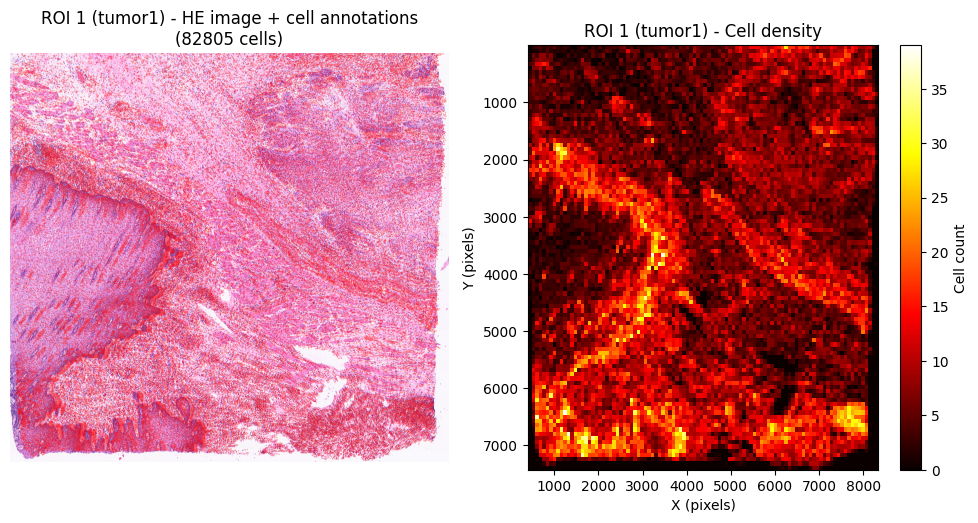

In [34]:
# Test visualization of ROI
print("Visualizing ROI 1")
fig = visualize_roi_cells(1, roi_dict, he_image_path=he_image_path, 
                          pixel_size_um=pixel_size_um, 
                          width_PCF=width_PCF, height_PCF=height_PCF, width_HE=width_HE, height_HE=height_HE,
                          figsize=(10, 5.2))
plt.show()